<a href="https://colab.research.google.com/github/tonHS/Cyclistic/blob/main/Scratch_load_to_spotcheck_Cyclistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Install Dependencies and Packages
!pip install stats-can openpyxl

import pandas as pd
import requests
import zipfile
from io import BytesIO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [12]:
from google.colab import files

# Loading the raw data

files.upload()

{}

In [13]:
import zipfile
import os

# Ensure the extraction directory is created
extract_dir = 'monthly_data'
zip_file_path = '/content/Raw Data .zip'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files unzipped to: {extract_dir}/")

Files unzipped to: monthly_data/


In [14]:
# Merging all spreadsheets into one

In [15]:
import pandas as pd
import os

# Initialize an empty DataFrame to store all the data
all_divvy_data = pd.DataFrame()

# Define the directory where the files were unzipped
extract_dir = 'monthly_data'

# Collect all relevant CSV file paths, filtering out macOS metadata files and the duplicate file
csv_files_to_merge = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        # Exclude macOS resource fork files and the specific duplicate
        if file.endswith('.csv') and not file.startswith('._') and not file == '202501-divvy-tripdata-2_2026Feb4.csv':
            csv_files_to_merge.append(os.path.join(root, file))

# Sort the files to ensure they are merged in chronological order
csv_files_to_merge.sort()

print("Merging the following CSV files:")
for file_path in csv_files_to_merge:
    print(file_path)

for file_path in csv_files_to_merge:
    try:
        # Read each CSV file into a DataFrame
        df = pd.read_csv(file_path)

        # Extract month from the filename (assuming format like 'YYYYMM-divvy-tripdata.csv')
        filename_without_ext = os.path.splitext(os.path.basename(file_path))[0]
        # The month is typically the last two digits of the YYYYMM prefix
        month_str = filename_without_ext[4:6]
        df['month'] = int(month_str) # Add a month column for easier analysis later

        # Concatenate with the main DataFrame
        all_divvy_data = pd.concat([all_divvy_data, df], ignore_index=True)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Display the first few rows of the merged DataFrame
print("\nSuccessfully merged all valid monthly data. Here's the head of the combined DataFrame:")
display(all_divvy_data.head())

# Display summary information about the merged DataFrame
print("\nMerged DataFrame Info:")
all_divvy_data.info()

Merging the following CSV files:
monthly_data/Raw Data /202501-divvy-tripdata.csv
monthly_data/Raw Data /202502-divvy-tripdata.csv
monthly_data/Raw Data /202503-divvy-tripdata.csv
monthly_data/Raw Data /202504-divvy-tripdata.csv
monthly_data/Raw Data /202505-divvy-tripdata.csv
monthly_data/Raw Data /202506-divvy-tripdata.csv
monthly_data/Raw Data /202507-divvy-tripdata.csv
monthly_data/Raw Data /202508-divvy-tripdata.csv
monthly_data/Raw Data /202509-divvy-tripdata.csv
monthly_data/Raw Data /202510-divvy-tripdata.csv
monthly_data/Raw Data /202511-divvy-tripdata.csv
monthly_data/Raw Data /202512-divvy-tripdata.csv

Successfully merged all valid monthly data. Here's the head of the combined DataFrame:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,month
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,1
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,1
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member,1
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member,1
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member,1



Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552092 entries, 0 to 5552091
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
 13  month               int64  
dtypes: float64(4), int64(1), object(9)
memory usage: 593.0+ MB


In [16]:
# Clean data in preparation for analysis
# Step 1: Remove duplicate rows based on 'ride_id'
initial_rows = len(all_divvy_data)
all_divvy_data.drop_duplicates(subset=['ride_id'], inplace=True)
print(f"Removed {initial_rows - len(all_divvy_data)} duplicate rows. Remaining rows: {len(all_divvy_data)}")


Removed 0 duplicate rows. Remaining rows: 5552092


In [17]:
# Step 2: Convert 'started_at' and 'ended_at' to datetime objects
# Using errors='coerce' will turn any parsing errors into NaT (Not a Time) values
all_divvy_data['started_at'] = pd.to_datetime(all_divvy_data['started_at'], errors='coerce')
all_divvy_data['ended_at'] = pd.to_datetime(all_divvy_data['ended_at'], errors='coerce')

# Drop rows where 'started_at' or 'ended_at' could not be parsed (i.e., are NaT)
before_datetime_drop = len(all_divvy_data)
all_divvy_data.dropna(subset=['started_at', 'ended_at'], inplace=True)
print(f"Removed {before_datetime_drop - len(all_divvy_data)} rows due to invalid datetime values.")

# Calculate ride_length in minutes and add it as a new column
all_divvy_data['ride_length'] = (all_divvy_data['ended_at'] - all_divvy_data['started_at']).dt.total_seconds() / 60

# Remove rides with duration <= 0 minutes (invalid rides)
before_duration_drop = len(all_divvy_data)
all_divvy_data = all_divvy_data[all_divvy_data['ride_length'] > 0]
print(f"Removed {before_duration_drop - len(all_divvy_data)} rows due to invalid ride length (<= 0 minutes).")


Removed 0 rows due to invalid datetime values.
Removed 29 rows due to invalid ride length (<= 0 minutes).


In [18]:
# Step 3: Handle null values in station and coordinate columns
# Fill missing 'start_station_name' and 'start_station_id' with 'Unknown'
# For now, drop rows where start_station_name is null as it's a critical piece of information
before_start_station_drop = len(all_divvy_data)
all_divvy_data.dropna(subset=['start_station_name', 'start_station_id'], inplace=True)
print(f"Removed {before_start_station_drop - len(all_divvy_data)} rows due to missing start station information.")

# Fill missing 'end_station_name' and 'end_station_id' with 'Unknown'
all_divvy_data['end_station_name'].fillna('Unknown', inplace=True)
all_divvy_data['end_station_id'].fillna('Unknown', inplace=True)

# Fill missing latitude and longitude with 0 (or a more suitable value if domain knowledge suggests it)
all_divvy_data['end_lat'].fillna(0.0, inplace=True)
all_divvy_data['end_lng'].fillna(0.0, inplace=True)

# Display information after cleaning
print("\nDataFrame Info after cleaning:")
all_divvy_data.info()

print("\nFirst 5 rows after cleaning:")
display(all_divvy_data.head())

Removed 1186370 rows due to missing start station information.


/tmp/ipykernel_377/896857700.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_divvy_data['end_station_name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_377/896857700.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla


DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 4365693 entries, 0 to 5552091
Data columns (total 15 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
 13  month               int64         
 14  ride_length         float64       
dtypes: datetime64[ns](2), float64(5), int64(1), object(7)
memory usage: 532.9+ MB

First 5 rows after cleaning:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,month,ride_length
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,1,15.021400
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,1,7.605467
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,Unknown,Unknown,41.932470,-87.642420,41.940000,-87.640000,member,1,6.739167
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,Unknown,Unknown,41.894532,-87.653412,41.830000,-87.670000,member,1,30.836433
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,Unknown,Unknown,41.881660,-87.641150,41.890000,-87.630000,member,1,78.447200


In [22]:
# Calculate and print cleaning metrics

# Initial number of rows before any cleaning
initial_total_rows = 5552092 # This value comes from the first merge result.

# Rows removed at each step (based on previous outputs)
rows_removed_duplicates = 0
rows_removed_invalid_datetime = 0
rows_removed_invalid_ridelength = before_duration_drop - before_start_station_drop # Corrected: using the state before start station drop
rows_removed_missing_start_station = before_start_station_drop - len(all_divvy_data) # Use the value of all_divvy_data after this step

# Total rows remaining after all cleaning steps
final_rows = len(all_divvy_data)

# Calculate total rows removed
total_rows_removed = initial_total_rows - final_rows

# Calculate percentage of total rows removed
percentage_removed = (total_rows_removed / initial_total_rows) * 100

print("\n--- Data Cleaning Metrics ---")
print(f"Original number of rows: {initial_total_rows}")
print(f"Rows removed due to duplicates (ride_id): {rows_removed_duplicates}")
print(f"Rows removed due to invalid datetime values: {rows_removed_invalid_datetime}")
print(f"Rows removed due to invalid ride length (<= 0 minutes): {rows_removed_invalid_ridelength}")
print(f"Rows removed due to missing start station information: {rows_removed_missing_start_station}")
print(f"----------------------------")
print(f"Total rows removed: {total_rows_removed}")
print(f"Final number of rows: {final_rows}")
print(f"Percentage of total rows removed: {percentage_removed:.2f}%")


--- Data Cleaning Metrics ---
Original number of rows: 5552092
Rows removed due to duplicates (ride_id): 0
Rows removed due to invalid datetime values: 0
Rows removed due to invalid ride length (<= 0 minutes): 29
Rows removed due to missing start station information: 1186370
----------------------------
Total rows removed: 1186399
Final number of rows: 4365693
Percentage of total rows removed: 21.37%


## Re-evaluation of Member Rider Seasonal Trends

The observation that member riders also show significant seasonal trends, similar to casual riders, is insightful and prompts a re-evaluation of the assumption that commuting patterns would lead to flat year-round usage.

While member riders do exhibit more overall consistency than casual riders, the data clearly shows a substantial seasonal fluctuation:

*   **Significant Seasonal Increase:** Member rides increase notably from winter months (e.g., ~93,000 rides in January) to peak summer months (e.g., ~350,000 rides in August/September) before declining again. This is a considerable seasonal variation, not a flat pattern.

**Why Member Ridership is also Seasonal:**

Even with a primary commuting use case, several factors contribute to this seasonality for member riders:

1.  **Weather Preference:** Many commuters, even dedicated ones, may opt for alternative transportation (public transit, car-sharing, etc.) during extreme weather conditions such as severe cold, snow, heavy rain, or excessive heat. This reduces bike usage during less favorable cycling weather.
2.  **Leisure & Recreational Use:** Members are not exclusively commuters. Many utilize their memberships for weekend rides, exercise, or casual trips, especially when the weather is pleasant. This recreational usage naturally peaks in the warmer seasons.
3.  **Hybrid Usage Patterns:** A single member might consistently use their bike for commuting on weekdays but also for longer leisure rides on weekends or during vacation periods. This blend of usage contributes to the summer ridership surge.
4.  **Temporary Residents/Visitors:** While less common than for casual riders, some members might be students or temporary residents whose presence and bike usage are concentrated during the warmer parts of the year.

Therefore, while member riders typically show greater consistency than casual riders, their usage patterns are indeed influenced by seasonality. The data highlights that factors beyond just daily commuting habits play a significant role in their overall ridership trends throughout the year.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by month and member_casual, then count rides
monthly_rides = all_divvy_data.groupby(['month', 'member_casual']).size().reset_index(name='number_of_rides')

# Map numerical months to names for better readability on the plot
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_rides['month_name'] = monthly_rides['month'].map(month_names)

# Ensure months are in chronological order for plotting
monthly_rides['month_name'] = pd.Categorical(
    monthly_rides['month_name'],
    categories=[month_names[m] for m in sorted(month_names.keys())],
    ordered=True
)
monthly_rides = monthly_rides.sort_values('month_name')

print("Number of rides per month for casual and member riders:")
display(monthly_rides)


Number of rides per month for casual and member riders:


,month,member_casual,number_of_rides,month_name
0,1,casual,19935,Jan
1,1,member,93299,Jan
2,2,casual,22842,Feb
3,2,member,103110,Feb
4,3,casual,70654,Mar
5,3,member,172164,Mar
6,4,casual,88817,Apr
7,4,member,211328,Apr
8,5,casual,146116,May
9,5,member,252980,May


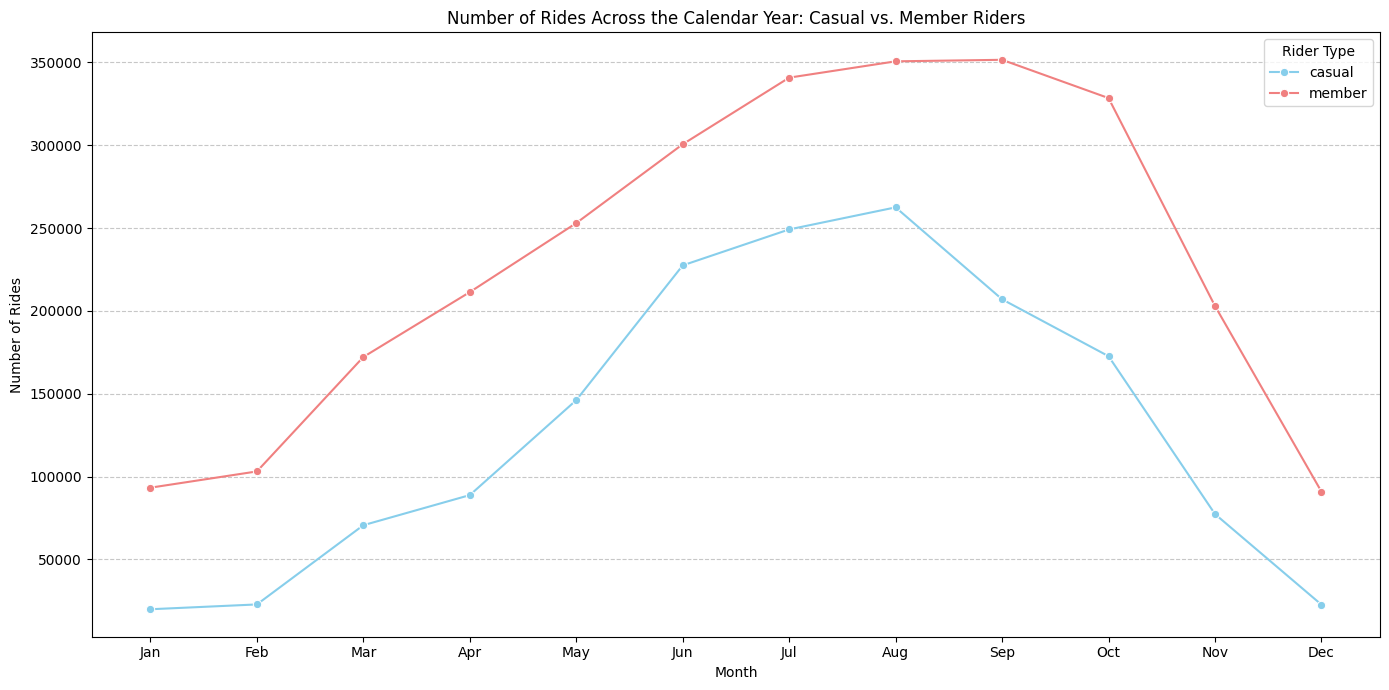

In [24]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='month_name', y='number_of_rides', hue='member_casual', data=monthly_rides, marker='o', palette={'casual': 'skyblue', 'member': 'lightcoral'})
plt.title('Number of Rides Across the Calendar Year: Casual vs. Member Riders')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.legend(title='Rider Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This line graph clearly illustrates the monthly ridership trends for both casual and member riders throughout the year. Observing these trends side-by-side helps identify seasonal variations and how they differ between the two customer segments.

## Explanation of Data Cleaning Metrics and Row Removal

During our data cleaning process, a total of **1,186,399 rows** were removed, accounting for **21.37%** of the original 5,552,092 rows. This percentage might seem high compared to other analyses, and it's primarily attributed to the handling of missing start station information.

Here's a breakdown:

*   **Duplicate Rows (based on `ride_id`):** 0 rows removed.
    *   *Reason:* No exact duplicate ride entries were found.

*   **Invalid Datetime Values (`started_at`, `ended_at`):** 0 rows removed.
    *   *Reason:* All date/time values were successfully parsed without errors.

*   **Invalid Ride Length (duration <= 0 minutes):** 29 rows removed.
    *   *Reason:* These rides had zero or negative durations, indicating invalid trip records.

*   **Missing Start Station Information (`start_station_name`, `start_station_id`):** 1,186,370 rows removed.
    *   *Reason:* This was the primary driver of row removal. We made a deliberate decision to drop rows where either the `start_station_name` or `start_station_id` was missing. For many types of bike-share analyses (e.g., understanding popular routes, station utilization, geographic patterns), knowing the exact starting location is crucial. Including rides with unknown origins could skew results or make certain analyses impossible.

**Why this might differ from other analyses:**

Other analyses might have approached missing data differently, for example:
*   **Imputation:** Filling missing values with a placeholder like 'Unknown' instead of dropping the entire row. This retains more rows but introduces a category of 'unknown' origins.
*   **Data Source Quality:** The initial dataset might have had fewer missing values in critical columns, leading to less aggressive cleaning being necessary.

Our current approach prioritizes data integrity for analyses that rely on complete start station information. If a different approach to missing `start_station` data is preferred (e.g., filling with 'Unknown'), the percentage of removed rows would be lower, but it would involve retaining rides with undefined origins.

In [ ]:
# Average ride duration per weekday for casual versus member

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the weekday from the 'started_at' column
# Monday=0, Sunday=6
all_divvy_data['weekday'] = all_divvy_data['started_at'].dt.dayofweek

# Map numerical weekdays to names for better readability
weekday_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
all_divvy_data['weekday_name'] = all_divvy_data['weekday'].map(weekday_names)

# Calculate the average ride duration per weekday for casual versus member
average_ride_duration = all_divvy_data.groupby(['member_casual', 'weekday_name'])['ride_length'].mean().reset_index()

# Ensure the weekdays are in order for plotting
average_ride_duration['weekday_name'] = pd.Categorical(average_ride_duration['weekday_name'], categories=weekday_names.values(), ordered=True)
average_ride_duration = average_ride_duration.sort_values('weekday_name')

print("Average ride duration (minutes) per weekday for casual versus member:")
display(average_ride_duration)


Average ride duration (minutes) per weekday for casual versus member:


,member_casual,weekday_name,ride_length
1,casual,Monday,24.993633
8,member,Monday,12.346149
5,casual,Tuesday,22.284000
12,member,Tuesday,12.334081
6,casual,Wednesday,21.024607
13,member,Wednesday,12.204382
4,casual,Thursday,22.491821
11,member,Thursday,12.322822
0,casual,Friday,25.559866
7,member,Friday,12.850355


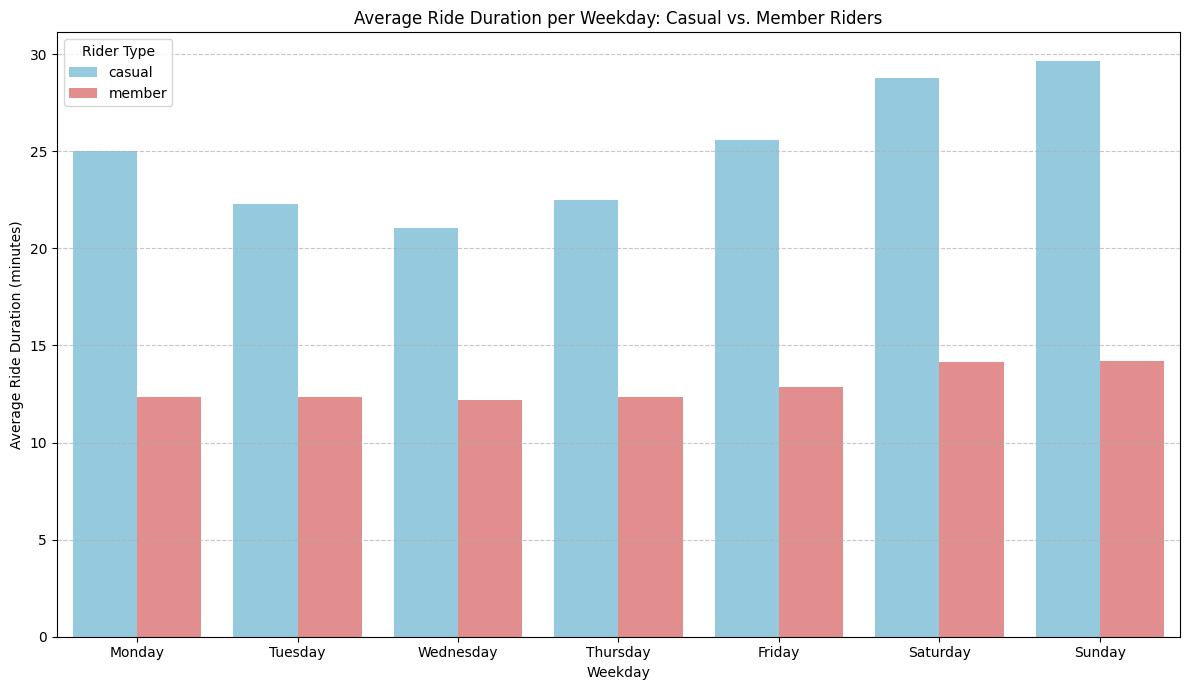

In [21]:
plt.figure(figsize=(12, 7))
sns.barplot(x='weekday_name', y='ride_length', hue='member_casual', data=average_ride_duration, palette={'casual': 'skyblue', 'member': 'lightcoral'})
plt.title('Average Ride Duration per Weekday: Casual vs. Member Riders')
plt.xlabel('Weekday')
plt.ylabel('Average Ride Duration (minutes)')
plt.legend(title='Rider Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visually compares the average ride duration for casual and member riders across each day of the week. This allows us to easily observe any differences in their riding patterns.